## Generate load condition time series

- During the day, the system operations at partial load conditions (50% of the rated power).
- During the night, the system operations at full load conditions (100% of the rated power).

On the other hand, the vapor temperature is set to some nominal value.


TODO: Include mv_kgs to avoid having to calculate it every time

In [1]:
import copy
import datetime
from pathlib import Path
from loguru import logger
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from suntime import Sun
from iapws import IAPWS97 as w_props

# Constants
output_path: Path = Path("../../data/datasets")
latitude: float = 37.0947  # Tabernas, Spain
longitude: float = -2.3583
Q_nomimal: float = 200.0  # Nominal power of the cooling system, kWth
Q_partial: float = Q_nomimal * 0.5 # Partial load of the cooling system, kWth
Tv_nominal: float = 35 # Nominal temperature of vapor, ºC

year_start: int = 2022
year_end: int = 2024


## Load power

In [ ]:
# Initialize Sun object
sun = Sun(latitude, longitude)

# Create a pandas series with one-hour resolution
start_date = datetime.datetime(year_start, 1, 1, 0, 0, 0)
end_date = datetime.datetime(year_end, 12, 31, 23, 0, 0)
date_rng = pd.date_range(start=start_date, end=end_date, freq='h', tz='UTC')

# Initialize thermal load series (default to Pn)
Q = pd.Series(Q_nomimal, index=date_rng, dtype=float)

# Compute sunrise & sunset for each day
sunrise_times = {}
sunset_times = {}

for single_date in pd.date_range(start=start_date, end=end_date, freq='D'):
    single_date0 = copy.deepcopy(single_date)
    
    sunrise = sun.get_sunrise_time(single_date)# .replace(tzinfo=datetime.timezone.utc)
    sunset = sun.get_sunset_time(single_date)# .replace(tzinfo=datetime.timezone.utc)

    sunrise_times[single_date.date()] = sunrise.replace(tzinfo=datetime.timezone.utc)
    sunset_times[single_date.date()] = sunset.replace(tzinfo=datetime.timezone.utc)
    
    assert single_date == single_date0, "single_date modified!"
    assert sunset_times[single_date.date()] > sunrise_times[single_date.date()], "Sunset before sunrise!"

print("First sunrise entry:", list(sunrise_times.items())[0])
print("First sunset entry:", list(sunset_times.items())[0])

print("Last sunrise entry:", list(sunrise_times.items())[-1])
print("Last sunset entry:", list(sunset_times.items())[-1])


First sunrise entry: (datetime.date(2022, 1, 1), datetime.datetime(2022, 1, 1, 7, 23, tzinfo=datetime.timezone.utc))
First sunset entry: (datetime.date(2022, 1, 1), datetime.datetime(2022, 1, 1, 17, 3, tzinfo=datetime.timezone.utc))
Last sunrise entry: (datetime.date(2024, 12, 31), datetime.datetime(2024, 12, 31, 7, 23, tzinfo=datetime.timezone.utc))
Last sunset entry: (datetime.date(2024, 12, 31), datetime.datetime(2024, 12, 31, 17, 3, tzinfo=datetime.timezone.utc))


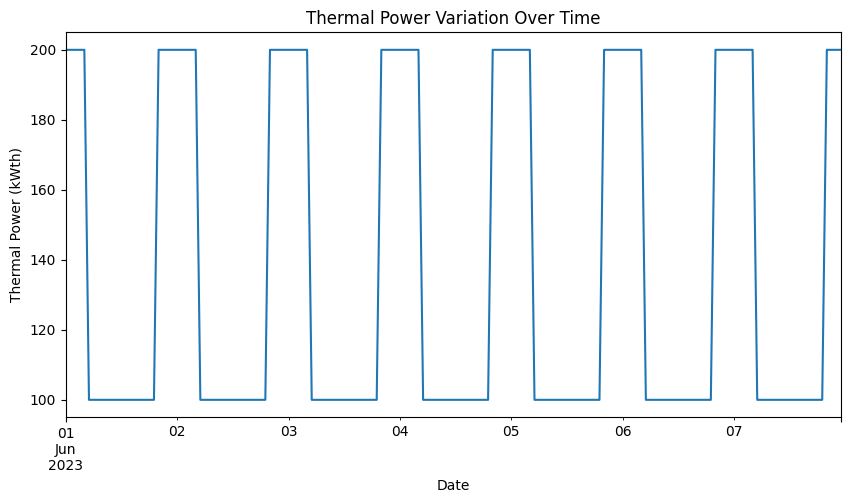

In [3]:
# Convert dictionaries to Series indexed by date
sunrise_series = pd.Series(sunrise_times).dt.tz_convert('UTC')
sunset_series = pd.Series(sunset_times).dt.tz_convert('UTC')

# Ensure the index of Q aligns with the datetime range
date_index = Q.index

# Get the sunrise and sunset times for each timestamp
sunrise_match = sunrise_series.reindex(date_index.date, method="ffill").values
sunset_match = sunset_series.reindex(date_index.date, method="ffill").values

# Create a Boolean mask where the condition is met
mask = (date_index.values >= sunrise_match) & (date_index.values <= sunset_match)

# Update Q using vectorized assignment
Q.loc[mask] = Q_partial

# Plot the results
plt.figure(figsize=(10, 5))
Q['2023-06-01':'2023-06-07'].plot()
plt.xlabel("Date")
plt.ylabel("Thermal Power (kWth)")
plt.title("Thermal Power Variation Over Time")
plt.show()


## Vapor temperature

In [ ]:
Tv = pd.Series(np.full(len(Q), Tv_nominal), index=date_rng, dtype=float)


## Vapor mass flow rate

In [ ]:
mv = np.array(
    [pth / (w_props(T=tv+273.15, x=1).h - w_props(T=tv+273.15, x=0).h) * 3600 for pth, tv in zip(Q, Tv)]
)


In [4]:

df_load = pd.DataFrame({'Q_kW': Q, 'Tv_C': Tv})

logger.info(f"Resulting dataframe has {len(df_load)} rows")

# Save to hdf5 and csv
fname = f"thermal_load_data_{df_load.index[0].strftime('%Y%m%d')}_{df_load.index[-1].strftime('%Y%m%d')}"
df_load.sort_index(inplace=True)
df_load.to_hdf(output_path / f"{fname}.h5", key="data", mode="w", format="table")
df_load.to_csv(output_path / f"{fname}.csv")
    
logger.info(f"Saved {fname} to {output_path}")

df_load


2025-02-28 14:48:13.556 | INFO     | __main__:<module>:5 - Resulting dataframe has 26304 rows
2025-02-28 14:48:13.749 | INFO     | __main__:<module>:13 - Saved thermal_load_data_20220101_20241231 to ../../data/datasets


,Q_kW,Tv_C
2022-01-01 00:00:00+00:00,200.0,35.0
2022-01-01 01:00:00+00:00,200.0,35.0
2022-01-01 02:00:00+00:00,200.0,35.0
2022-01-01 03:00:00+00:00,200.0,35.0
2022-01-01 04:00:00+00:00,200.0,35.0
...,...,...
2024-12-31 19:00:00+00:00,200.0,35.0
2024-12-31 20:00:00+00:00,200.0,35.0
2024-12-31 21:00:00+00:00,200.0,35.0
2024-12-31 22:00:00+00:00,200.0,35.0


In [6]:
df = pd.read_hdf(output_path / f"{fname}.h5", index_col=0, parse_dates=True)
df


,Q_kW,Tv_C
2022-01-01 00:00:00+00:00,200.0,35.0
2022-01-01 01:00:00+00:00,200.0,35.0
2022-01-01 02:00:00+00:00,200.0,35.0
2022-01-01 03:00:00+00:00,200.0,35.0
2022-01-01 04:00:00+00:00,200.0,35.0
...,...,...
2024-12-31 19:00:00+00:00,200.0,35.0
2024-12-31 20:00:00+00:00,200.0,35.0
2024-12-31 21:00:00+00:00,200.0,35.0
2024-12-31 22:00:00+00:00,200.0,35.0


In [8]:
# Visualize data
from plotly_resampler import FigureWidgetResampler
from plotly.subplots import make_subplots
import plotly.graph_objects as go

var_ids: list[str] = ["Q_kW", "Tv_C"]
var_units: list[str] = [r"kW<sub>th</sub>", "°C"]

fig = make_subplots(rows=len(var_ids), cols=1, shared_xaxes=True)
fig = FigureWidgetResampler(fig)

for i, (var_id, var_unit) in enumerate(zip(var_ids, var_units)):
    fig.add_trace(
        go.Scattergl(name=var_id, showlegend=True), 
        hf_x=df.index, 
        hf_y=np.ascontiguousarray(df[var_id]), 
        # max_n_samples=2_000,
        row=i + 1, col=1
    )
    fig.update_yaxes(title_text=f"{var_id.replace("_", " ")} ({var_unit})", row=i + 1)

fig.update_layout(
    height=650,
    width=800,
    title="<b>Thermal load</b>",
    title_x=0.1,
    legend_traceorder="normal",
    legend=dict(orientation="h", y=1.08, xanchor="left", x=0),
)

fig


FigureWidgetResampler({
    'data': [{'name': '<b style="color:sandybrown">[R]</b> Q_kW <i style="color:#fc9944">~1D</i>',
              'showlegend': True,
              'type': 'scattergl',
              'uid': '8c662219-4731-4b79-b79d-845f4713799b',
              'x': array([datetime.datetime(2022, 1, 1, 0, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 1, 8, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2022, 1, 2, 4, 0, tzinfo=datetime.timezone.utc), ...,
                          datetime.datetime(2024, 12, 29, 8, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 31, 9, 0, tzinfo=datetime.timezone.utc),
                          datetime.datetime(2024, 12, 31, 23, 0, tzinfo=datetime.timezone.utc)],
                         shape=(1000,), dtype=object),
              'xaxis': 'x',
              'y': array([200., 100., 200., ..., 100., 100., 200.], shape=(1000,)),
         

In [7]:
from phd_visualizations import save_figure

start, end = fig.layout.xaxis.range
save_figure(fig, f"solhycool_thermal_load_viz_{start[:10].replace('-', '')}_{end[:10].replace('-', '')}", 
            figure_path=Path("../results"), formats=["png", "svg"])


TypeError: cannot unpack non-iterable NoneType object